No video stop event found — defaulting to 600 s duration


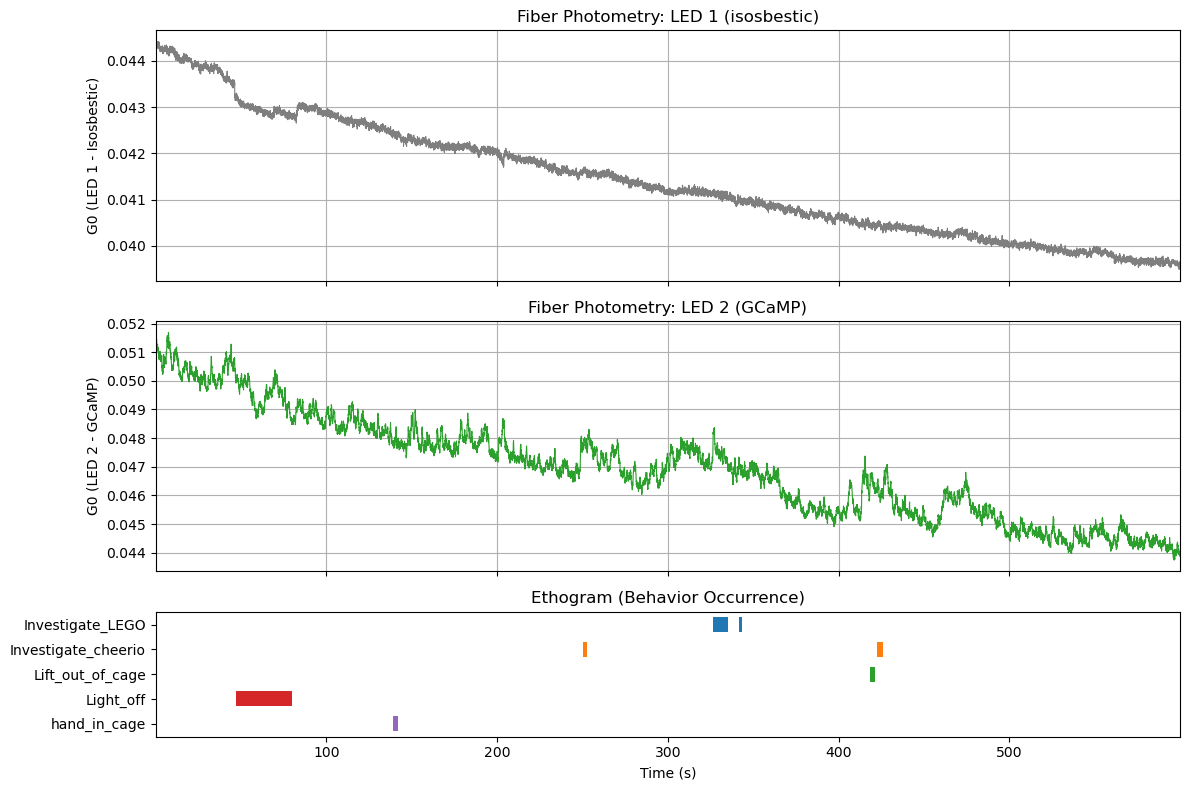

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial1/OFT_FP1.csv"
ts_path = "Trial1/timestamp0.csv"
eth_path = "Trial1/Raw data-Photbleaching_C3_20260527-Trial     3.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


No video stop event found — defaulting to 600 s duration


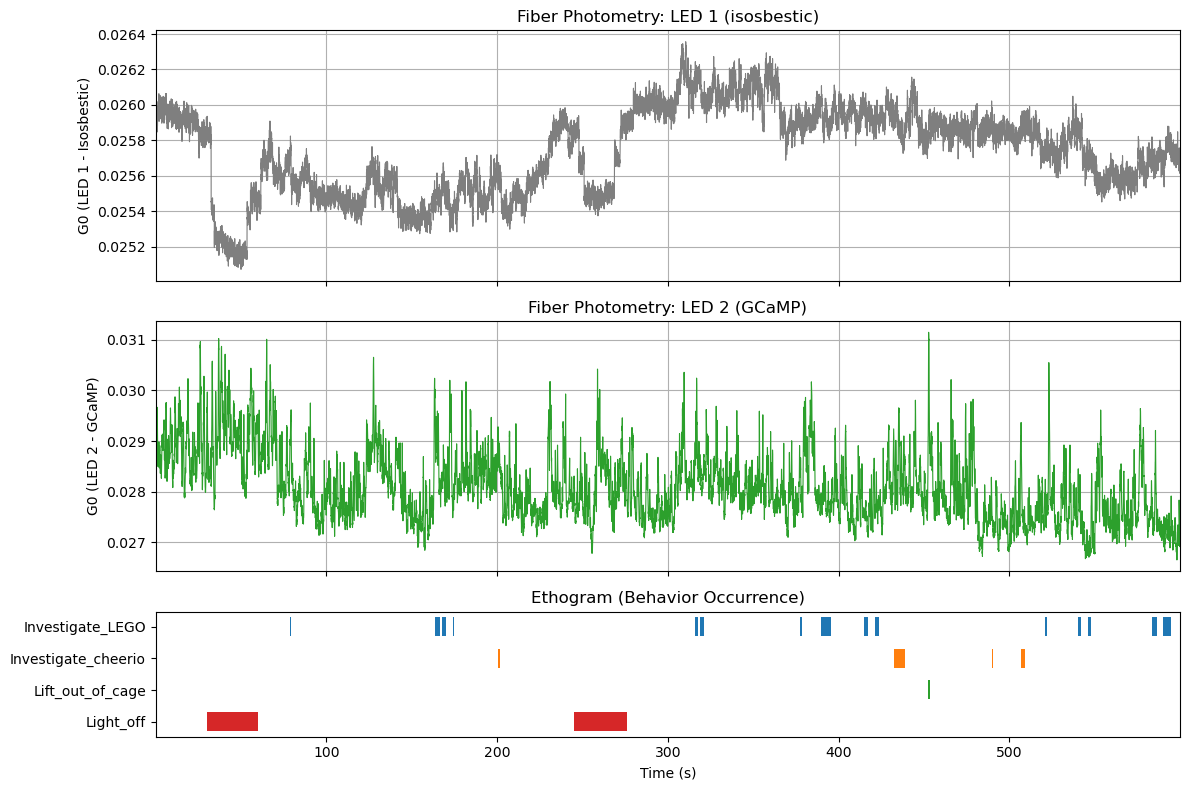

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial2/OFT_FP2.csv"
ts_path = "Trial2/timestamp0.csv"
eth_path = "Trial2/Raw data-Photbleaching_C3_20260527-Trial     4.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


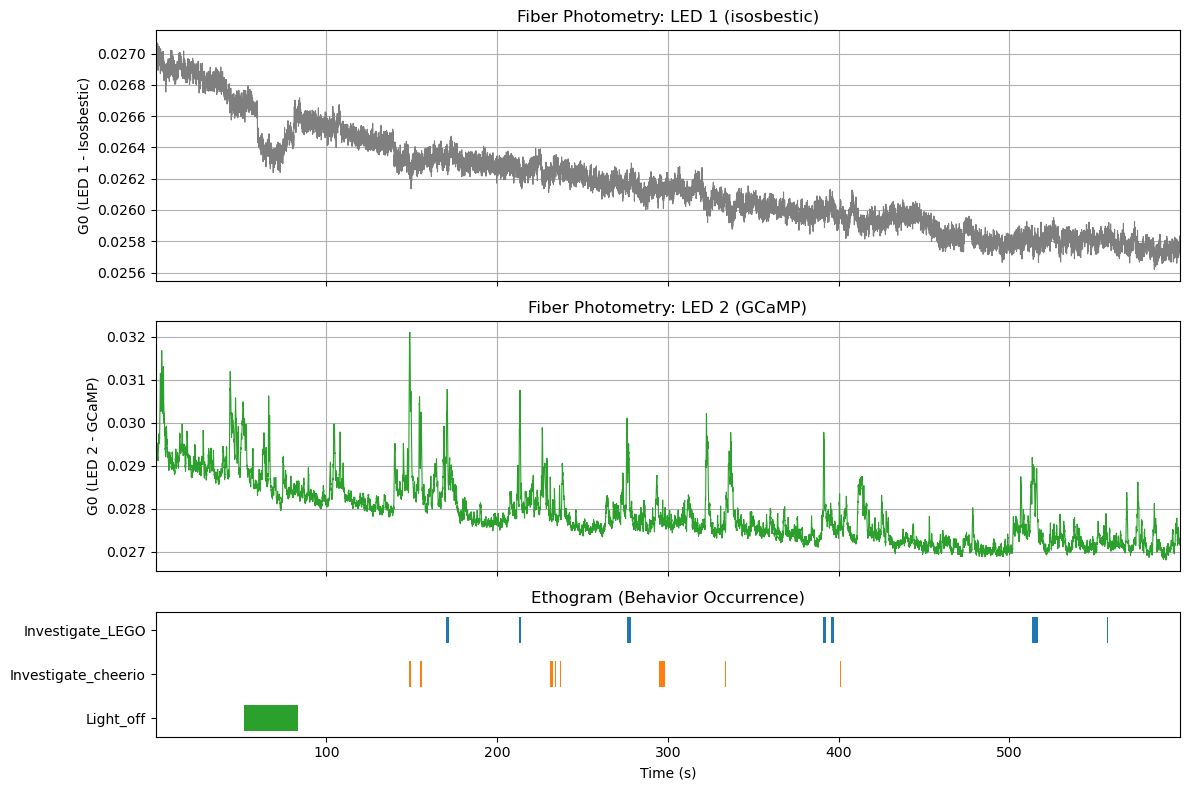

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial3/OFT_FP4.csv"
ts_path = "Trial3/timestamp0.csv"
eth_path = "Trial3/Raw data-Photbleaching_C3_20260527-Trial    10.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


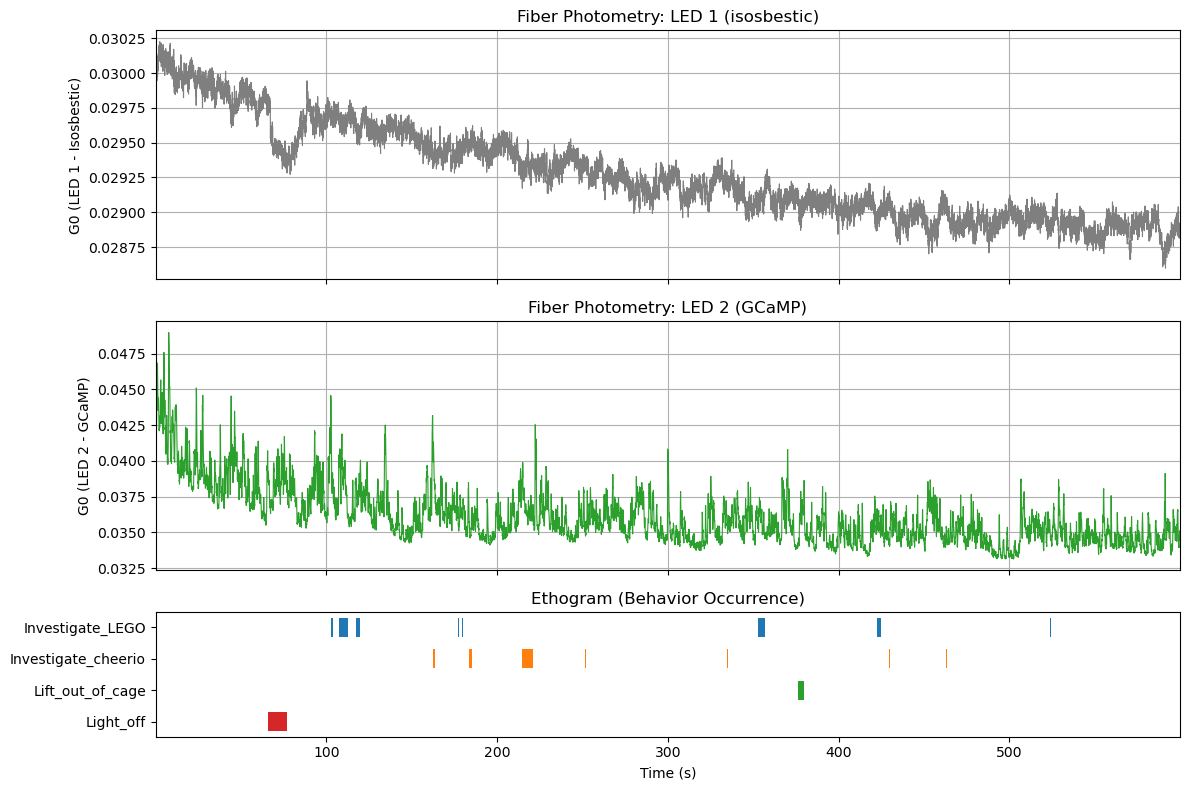

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial4/OFT_FP5.csv"
ts_path = "Trial4/timestamp0.csv"
eth_path = "Trial4/Raw data-Photbleaching_C3_20260527-Trial    11.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


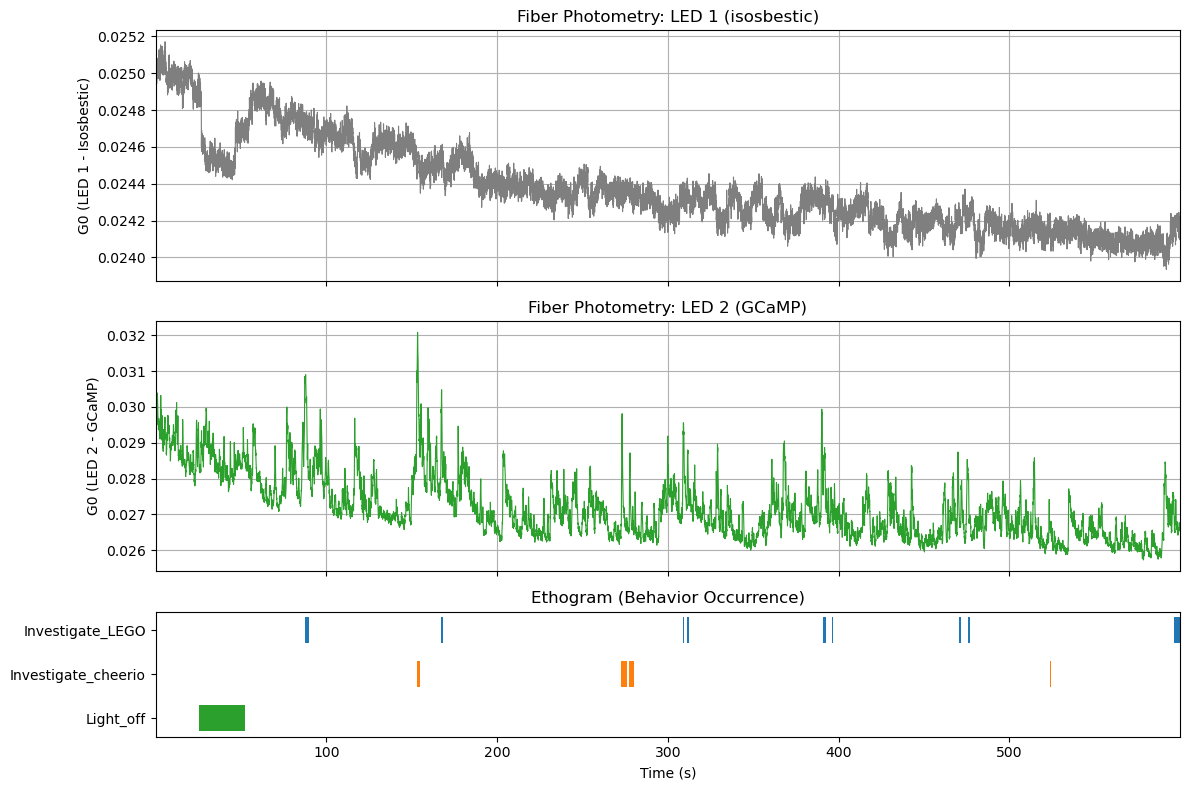

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial5/OFT_FP6.csv"
ts_path = "Trial5/timestamp0.csv"
eth_path = "Trial5/Raw data-Photbleaching_C3_20260527-Trial    12.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


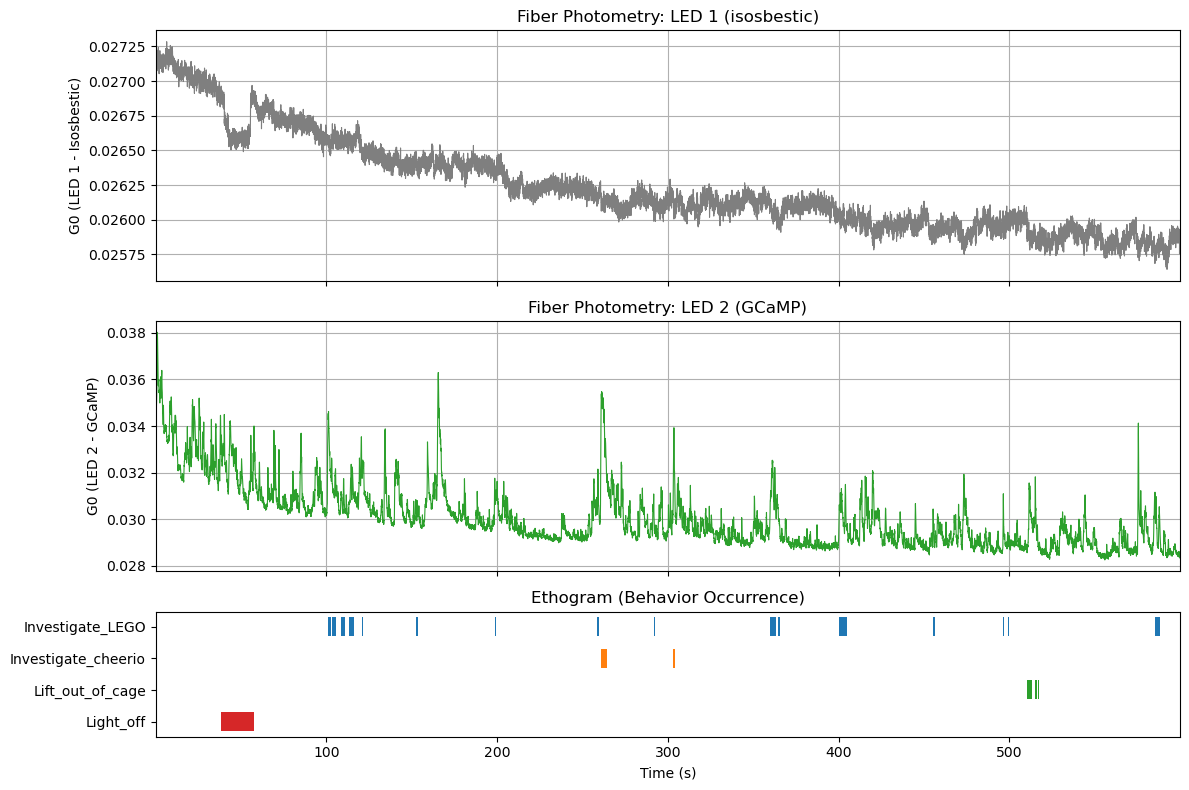

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial6/OFT_FP7.csv"
ts_path = "Trial6/timestamp0.csv"
eth_path = "Trial6/Raw data-Photbleaching_C3_20260527-Trial    13.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


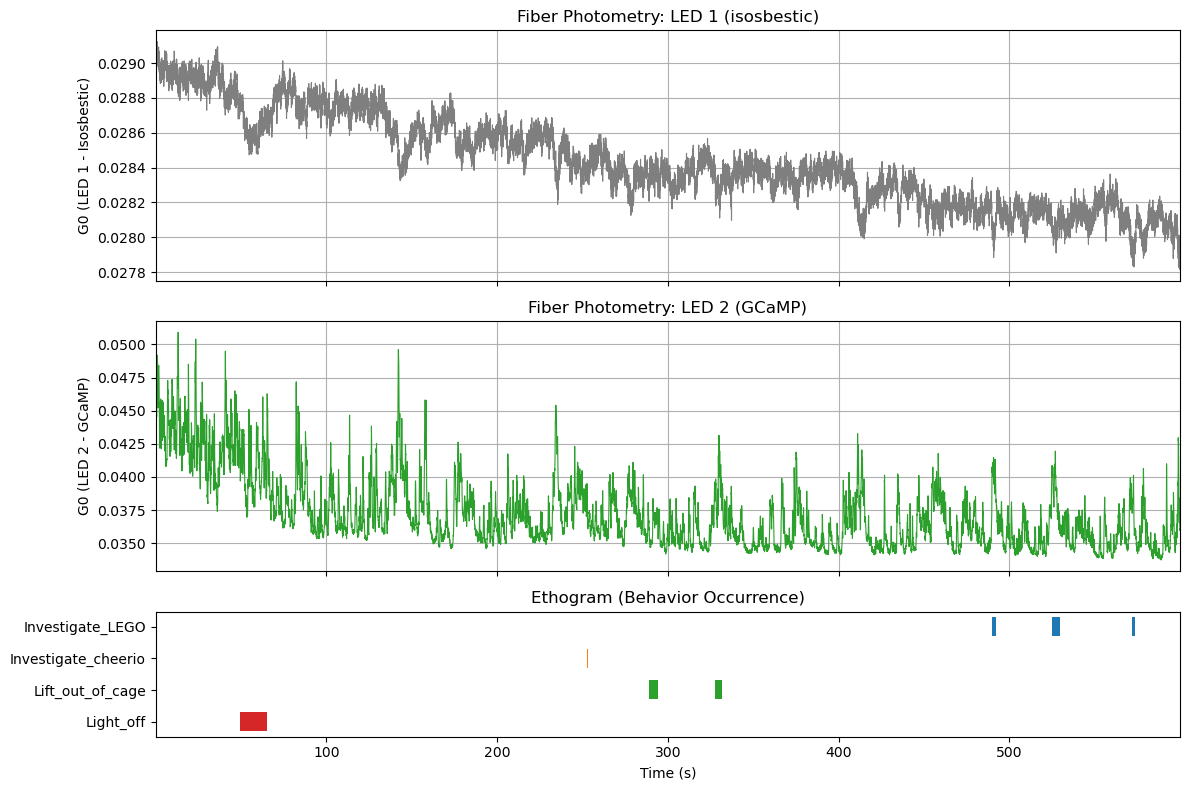

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial7/OFT_FP8.csv"
ts_path = "Trial7/timestamp0.csv"
eth_path = "Trial7/Raw data-Photbleaching_C3_20260527-Trial    14.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


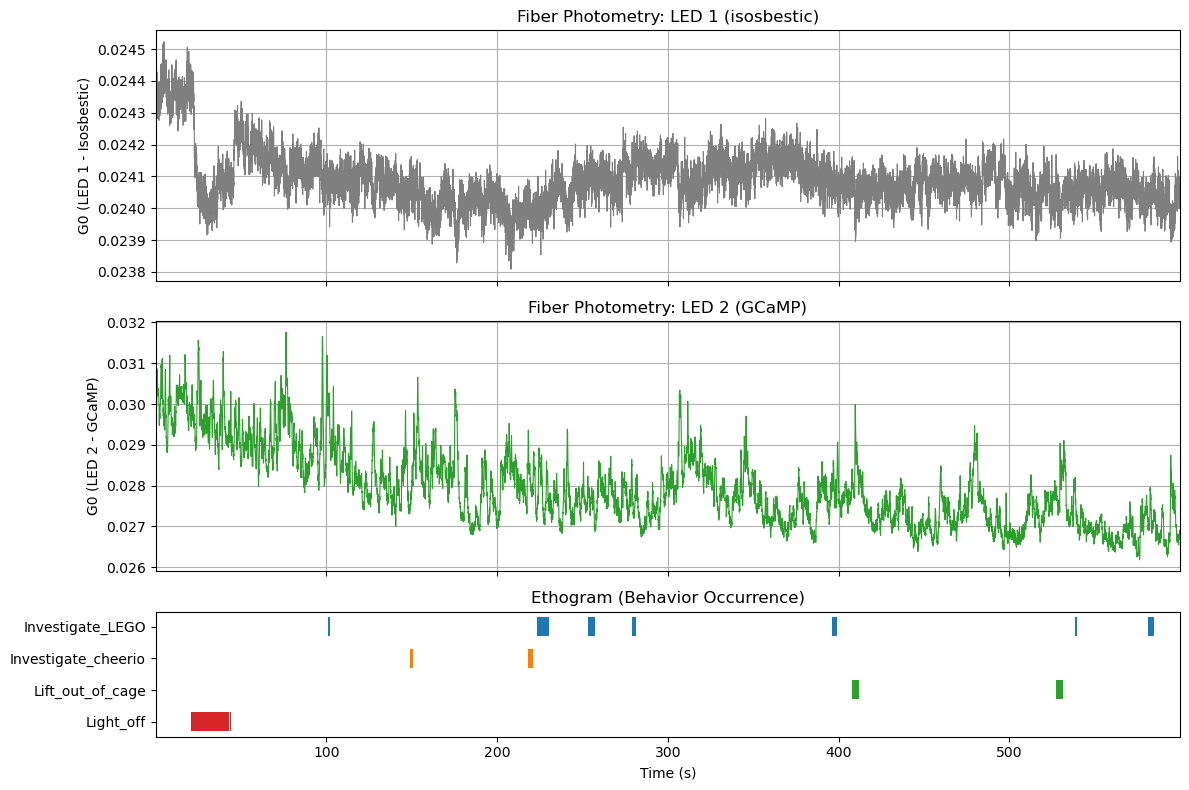

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial8/OFT_FP9.csv"
ts_path = "Trial8/timestamp1.csv"
eth_path = "Trial8/Raw data-Photbleaching_C3_20260527-Trial    15.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()


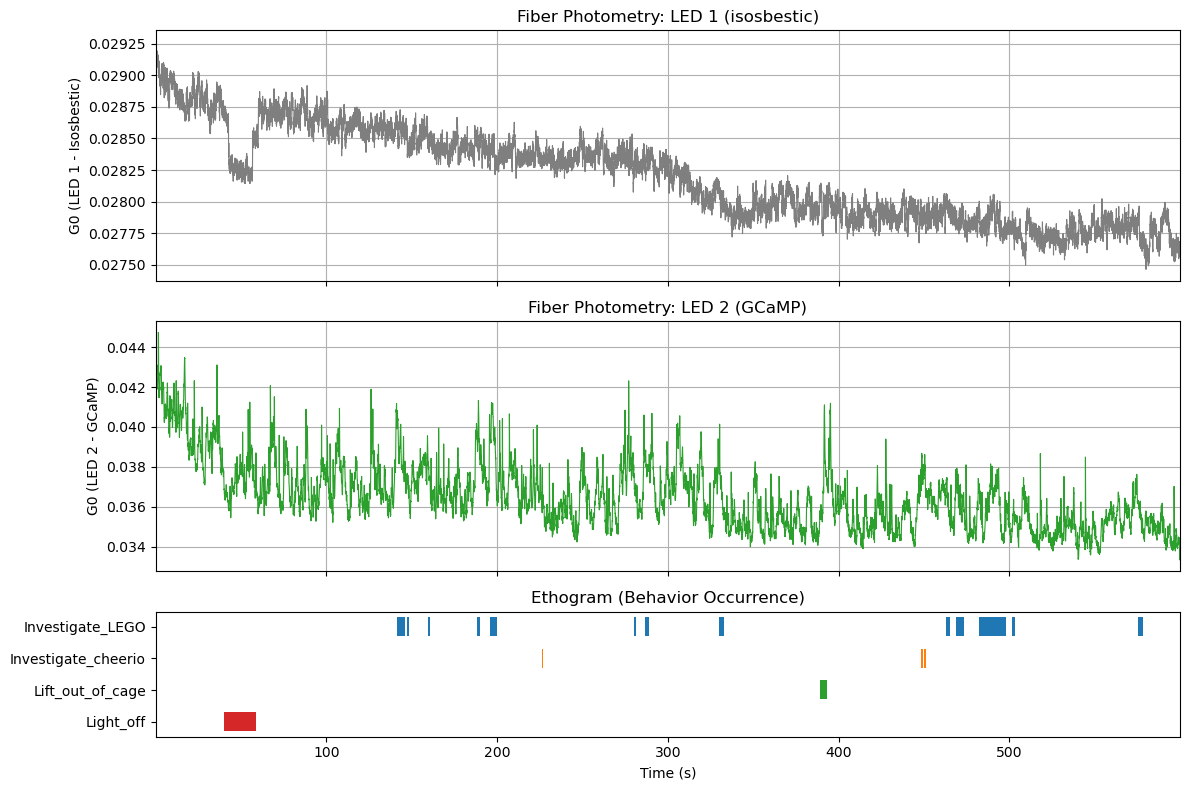

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. File paths and parameters
# -------------------------------------------------
fp_path = "Trial9/OFT_FP10.csv"
ts_path = "Trial9/timestamp0.csv"
eth_path = "Trial9/Raw data-Photbleaching_C3_20260527-Trial    16.xlsx"

behaviors_of_interest = [
    "Investigate_LEGO",
    "Investigate_cheerio",
    "Light_off",
    "Lift_out_of_cage",
    "hand_in_cage",
    "touch_mouse"
]

video_fps = 50.0  # EthoVision video frame rate
fp_fps = 50.0     # Fiber photometry overall rate (25 Hz per LED)

# -------------------------------------------------
# 2. Load and clean fiber photometry data
# -------------------------------------------------
fp = pd.read_csv(fp_path)
# Keep LED 1 and 2 only
fp = fp[fp["LedState"].isin([1, 2])].copy()
# Normalize time to start at 0
fp["Time_s"] = fp["SystemTimestamp"] - fp["SystemTimestamp"].min()

# -------------------------------------------------
# 3. Load timestamp alignment (video start/stop)
# -------------------------------------------------
# ts = pd.read_csv(ts_path)
# video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])
# video_stop  = float(ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"].iloc[0])

ts = pd.read_csv(ts_path)

video_start = float(ts.loc[ts["DigitalIOState"] == True, "SystemTimestamp"].iloc[0])

false_events = ts.loc[ts["DigitalIOState"] == False, "SystemTimestamp"]

if false_events.empty:
    print("No video stop event found — defaulting to 600 s duration")
    video_stop = video_start + 600.0
else:
    video_stop = float(false_events.iloc[0])

# Trim FP data to match video window
fp = fp[fp["SystemTimestamp"].between(video_start, video_stop)].copy()
fp["Time_video"] = fp["SystemTimestamp"] - video_start

# -------------------------------------------------
# 4. Load EthoVision data (header row 41)
# -------------------------------------------------
eth = pd.read_excel(eth_path, header=40)
eth = eth.dropna(axis=1, how="all")

# Identify the time column
time_col = next((c for c in eth.columns if "Time" in str(c)), None)
if time_col is None:
    eth["Time_s"] = np.arange(len(eth)) / video_fps
    time_col = "Time_s"
else:
    eth["Time_s"] = pd.to_numeric(eth[time_col], errors="coerce")

# Keep only specified behaviors that exist
beh_cols = [b for b in behaviors_of_interest if b in eth.columns]
if not beh_cols:
    print("Available columns:", list(eth.columns))
    raise ValueError("None of the specified behavior columns found in EthoVision data!")

eth = eth[["Time_s"] + beh_cols].copy()

# -------------------------------------------------
# 5. Prepare ethogram data for plotting
# -------------------------------------------------
segments = []
for beh in beh_cols:
    mask = eth[beh] == 1
    if mask.sum() == 0:
        continue
    diff = mask.astype(int).diff().fillna(0)
    starts = eth.loc[diff == 1, "Time_s"].values
    ends = eth.loc[diff == -1, "Time_s"].values
    if mask.iloc[0]:
        starts = np.insert(starts, 0, eth["Time_s"].iloc[0])
    if mask.iloc[-1]:
        ends = np.append(ends, eth["Time_s"].iloc[-1])
    for s, e in zip(starts, ends):
        segments.append({
            "Behavior": beh,
            "Start_time_s": float(s),
            "End_time_s": float(e),
            "Duration_s": float(e - s)
        })

timeline = pd.DataFrame(segments).sort_values(["Behavior", "Start_time_s"]).reset_index(drop=True)

# -------------------------------------------------
# 6. Plot FP traces (LED 1 & 2 separately) + ethogram
# -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1]})

# --- LED 1 (isosbestic) ---
fp1 = fp[fp["LedState"] == 1]
axes[0].plot(fp1["Time_video"], fp1["G0"], color="tab:gray", linewidth=0.8)
axes[0].set_ylabel("G0 (LED 1 - Isosbestic)")
axes[0].set_title("Fiber Photometry: LED 1 (isosbestic)")
axes[0].grid(True)

# --- LED 2 (GCaMP) ---
fp2 = fp[fp["LedState"] == 2]
axes[1].plot(fp2["Time_video"], fp2["G0"], color="tab:green", linewidth=0.8)
axes[1].set_ylabel("G0 (LED 2 - GCaMP)")
axes[1].set_title("Fiber Photometry: LED 2 (GCaMP)")
axes[1].grid(True)

# --- Ethogram (behaviors) ---
if not timeline.empty:
    behaviors = timeline["Behavior"].unique()
    colors = plt.cm.tab10.colors
    for i, beh in enumerate(behaviors):
        sub = timeline[timeline["Behavior"] == beh]
        for _, row in sub.iterrows():
            axes[2].barh(i, width=row["Duration_s"], left=row["Start_time_s"],
                         color=colors[i % len(colors)], height=0.6)
    axes[2].set_yticks(range(len(behaviors)))
    axes[2].set_yticklabels(behaviors)
    axes[2].set_xlabel("Time (s)")
    axes[2].set_title("Ethogram (Behavior Occurrence)")
    axes[2].invert_yaxis()

# --- Shared settings ---
axes[-1].set_xlim(fp["Time_video"].min(), fp["Time_video"].max())
plt.tight_layout()
plt.show()
